# Gradient Accumulation Experiment

Bu notebook, **standart egitim** ile **gradient accumulation** egitimini ayni efektif batch size altinda karsilastirir.

Karsilastirilan metrikler:
- Loss ve Accuracy
- Toplam/epoch/step sureleri
- Throughput (samples/sec, batches/sec)
- Donanim kullanimi (GPU VRAM, CPU, RAM)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

from functions.dataset import (
    COVIDCXNetDataset,
    DataLoaderConfig,
    build_transforms,
    create_dataloader,
    describe_class_distribution,
)
from functions.logging import ExperimentLogger, ExperimentLoggerConfig
from functions.train import TrainConfig, fit, set_seed

sns.set_theme(style='whitegrid')

In [2]:
CONFIG = {
    'csv_file': 'E:/covidx/covidx_merged.csv',
    'root_dir': 'E:/',
    'num_epochs': 5,
    'num_classes': 2,
    'lr': 1e-4,
    'seed': 42,
    'patience': 3,
    'image_size': 224,
    'output_dir': 'runs',
    'num_workers': None,
}

STANDARD = {
    'batch_size': 32,
    'accumulation_steps': 1,
    'run_name': 'standard_bs32_acc1',
}

ACCUM = {
    'batch_size': 8,
    'accumulation_steps': 4,
    'run_name': 'accum_bs8_acc4',
}

assert (
    STANDARD['batch_size'] * STANDARD['accumulation_steps']
    == ACCUM['batch_size'] * ACCUM['accumulation_steps']
), 'Effective batch size must be identical for a fair comparison.'

set_seed(CONFIG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Effective batch size: {STANDARD["batch_size"] * STANDARD["accumulation_steps"]}')

Using device: cuda
Effective batch size: 32


In [3]:
train_transform = build_transforms(image_size=CONFIG['image_size'], augment=True)
eval_transform = build_transforms(image_size=CONFIG['image_size'], augment=False)

train_dataset = COVIDCXNetDataset(
    csv_file=CONFIG['csv_file'],
    root_dir=CONFIG['root_dir'],
    transform=train_transform,
    split='train',
)

val_dataset = None
for split_name in ('val', 'validation', 'valid', 'test'):
    try:
        val_dataset = COVIDCXNetDataset(
            csv_file=CONFIG['csv_file'],
            root_dir=CONFIG['root_dir'],
            transform=eval_transform,
            split=split_name,
        )
        print(f'Validation split selected: {split_name}')
        break
    except ValueError:
        continue

if val_dataset is None:
    raise ValueError('No validation split found. Update split names in this cell.')

print('Train class distribution:', describe_class_distribution(train_dataset))
print('Val class distribution:', describe_class_distribution(val_dataset))

Validation split selected: val
Train class distribution: {'AP': 33303, 'PA': 20388}
Val class distribution: {'AP': 2911, 'PA': 1275}


In [4]:
def build_model(num_classes: int) -> nn.Module:
    model = models.resnet18(weights='DEFAULT')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def run_experiment(batch_size: int, accumulation_steps: int, run_name: str):
    train_loader = create_dataloader(
        train_dataset,
        DataLoaderConfig(
            batch_size=batch_size,
            shuffle=True,
            num_workers=CONFIG['num_workers'],
            drop_last=False,
        ),
        device=device,
    )

    val_loader = create_dataloader(
        val_dataset,
        DataLoaderConfig(
            batch_size=batch_size,
            shuffle=False,
            num_workers=CONFIG['num_workers'],
            drop_last=False,
        ),
        device=device,
    )

    model = build_model(CONFIG['num_classes'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'])

    logger = ExperimentLogger(
        ExperimentLoggerConfig(
            run_name=run_name,
            output_dir=CONFIG['output_dir'],
            overwrite=True,
        )
    )

    train_cfg = TrainConfig(
        use_amp=False,
        num_epochs=CONFIG['num_epochs'],
        accumulation_steps=accumulation_steps,
        patience=CONFIG['patience'],
        run_name=run_name,
        output_dir=CONFIG['output_dir'],
        log_every_n_steps=10,
        system_log_interval=50,
    )

    result = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        config=train_cfg,
        logger=logger,
        show_progress=True,
    )
    return result

## Standart Egitim

In [5]:
standard_result = run_experiment(
    batch_size=STANDARD['batch_size'],
    accumulation_steps=STANDARD['accumulation_steps'],
    run_name=STANDARD['run_name'],
)
standard_result

d:\Projects\ML_Algorithms\gradient_accumulation\amp_off\functions\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
[2026-02-28 05:36:14] Run 'standard_bs32_acc1' started | epochs=5, accumulation_steps=1, amp=False
Epoch 1 [train]:   0%|          | 0/1678 [00:00<?, ?it/s]d:\Projects\ML_Algorithms\gradient_accumulation\amp_off\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
[2026-02-28 05:38:11] Epoch 1/5 | train_loss=0.0988, train_acc=0.9689, val_loss=0.1275, val_acc=0.9618, epoch_time=90.27s, train_sps=594.80, peak_vram=1964.55MB
Epoch 2 [train]:   0%|          | 0/1678 [00:00<?, ?it/s]d:\Projects\ML_Algorithms\gradient_accumulation\amp_off\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is de

TrainingResult(run_name='standard_bs32_acc1', run_dir='runs\\standard_bs32_acc1', history={'train_loss': [0.09878857988575616, 0.06390475993106097, 0.05633971758332662, 0.05017941360755298, 0.044563944014583225], 'train_accuracy': [0.9689333407833716, 0.9816915311690972, 0.9835167905235515, 0.9853420498780057, 0.9867575571324803], 'val_loss': [0.12749833199911967, 0.1068279113957807, 0.12860089398486022, 0.10371492686176599, 0.1032726962810616], 'val_accuracy': [0.9617773530817009, 0.967032967032967, 0.9612995699952221, 0.9660774008600096, 0.9677496416626852], 'epoch_time_sec': [90.26717810000082, 66.21574180000061, 67.61077650000152, 67.19763800000146, 68.13387669999975], 'avg_step_time_sec': [0.03901136197855391, 0.0373288008939478, 0.03729567318238116, 0.03736277419542629, 0.037301340762826235], 'train_samples_per_sec': [594.8009135781272, 810.8494829246102, 794.1189671146402, 799.0012982301376, 788.0220912191277], 'train_batches_per_sec': [18.589259521783863, 25.34140605217813, 24.

## Gradient Accumulation Egitimi

In [6]:
accum_result = run_experiment(
    batch_size=ACCUM['batch_size'],
    accumulation_steps=ACCUM['accumulation_steps'],
    run_name=ACCUM['run_name'],
)
accum_result

d:\Projects\ML_Algorithms\gradient_accumulation\amp_off\functions\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
[2026-02-28 05:43:04] Run 'accum_bs8_acc4' started | epochs=5, accumulation_steps=4, amp=False
Epoch 1 [train]:   0%|          | 0/6712 [00:00<?, ?it/s]d:\Projects\ML_Algorithms\gradient_accumulation\amp_off\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
[2026-02-28 05:45:19] Epoch 1/5 | train_loss=0.1274, train_acc=0.9599, val_loss=0.1101, val_acc=0.9632, epoch_time=110.90s, train_sps=484.15, peak_vram=1360.04MB
Epoch 2 [train]:   0%|          | 0/6712 [00:00<?, ?it/s]d:\Projects\ML_Algorithms\gradient_accumulation\amp_off\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is depre

TrainingResult(run_name='accum_bs8_acc4', run_dir='runs\\accum_bs8_acc4', history={'train_loss': [0.127432355576379, 0.07551404430175859, 0.06420963688575611, 0.05780369898637594], 'train_accuracy': [0.9598629192974614, 0.9784507645601683, 0.9820454079827159, 0.983535415619005], 'val_loss': [0.11006337801565054, 0.11342883318983522, 0.13276922446521597, 0.12292784565727762], 'val_accuracy': [0.9632107023411371, 0.9603440038222647, 0.9567606306736741, 0.957955088389871], 'epoch_time_sec': [110.89683729999888, 95.13021970000045, 97.32510349999939, 101.05632160000096], 'avg_step_time_sec': [0.012088240226462724, 0.012037251281287253, 0.011945989302758824, 0.011976710563165113], 'train_samples_per_sec': [484.152671142052, 564.3947861081177, 551.6665081173054, 531.2977867185648], 'train_batches_per_sec': [60.52471976132784, 70.5559182052427, 68.96473529052084, 66.41840800981555], 'peak_vram_mb': [1360.0380859375, 383.7802734375, 383.7802734375, 383.7802734375]}, best_epoch=1, best_val_loss=

In [7]:
def load_run_tables(result):
    run_dir = Path(result.run_dir)
    step_df = pd.read_csv(run_dir / 'step_metrics.csv')
    epoch_df = pd.read_csv(run_dir / 'epoch_metrics.csv')
    system_df = pd.read_csv(run_dir / 'system_metrics.csv')
    summary = pd.read_json(run_dir / 'run_summary.json', typ='series')
    return step_df, epoch_df, system_df, summary


std_step, std_epoch, std_sys, std_summary = load_run_tables(standard_result)
acc_step, acc_epoch, acc_sys, acc_summary = load_run_tables(accum_result)


def summarize_run(name: str, epoch_df: pd.DataFrame, system_df: pd.DataFrame, summary: pd.Series):
    train_epoch = epoch_df[epoch_df['phase'] == 'train'].copy()
    val_epoch = epoch_df[epoch_df['phase'] == 'val'].copy()

    row = {
        'run': name,
        'best_epoch': summary.get('best_epoch', np.nan),
        'best_val_loss': summary.get('best_val_loss', np.nan),
        'total_train_time_sec': summary.get('total_train_time_sec', np.nan),
        'final_train_loss': train_epoch['loss'].iloc[-1] if len(train_epoch) else np.nan,
        'final_train_acc': train_epoch['accuracy'].iloc[-1] if len(train_epoch) else np.nan,
        'final_val_loss': val_epoch['loss'].iloc[-1] if len(val_epoch) else np.nan,
        'final_val_acc': val_epoch['accuracy'].iloc[-1] if len(val_epoch) else np.nan,
        'avg_epoch_time_sec': train_epoch['epoch_time_sec'].mean() if len(train_epoch) else np.nan,
        'avg_step_time_sec': train_epoch['avg_step_time_sec'].mean() if len(train_epoch) else np.nan,
        'avg_samples_per_sec': train_epoch['samples_per_sec'].mean() if len(train_epoch) else np.nan,
        'avg_batches_per_sec': train_epoch['batches_per_sec'].mean() if len(train_epoch) else np.nan,
        'peak_vram_mb': train_epoch['peak_vram_mb'].max() if len(train_epoch) else np.nan,
        'max_cpu_percent': system_df['cpu_percent'].max() if len(system_df) else np.nan,
        'max_ram_percent': system_df['ram_percent'].max() if len(system_df) else np.nan,
    }
    return row


comparison_df = pd.DataFrame([
    summarize_run('Standard', std_epoch, std_sys, std_summary),
    summarize_run('GradientAccum', acc_epoch, acc_sys, acc_summary),
])
comparison_df

,run,best_epoch,best_val_loss,total_train_time_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc,avg_epoch_time_sec,avg_step_time_sec,avg_samples_per_sec,avg_batches_per_sec,peak_vram_mb,max_cpu_percent,max_ram_percent
0,Standard,5,0.103273,408.701793,0.044564,0.986758,0.103273,0.967750,71.885042,0.037660,757.358551,23.669659,1964.549316,58.5,56.2
1,GradientAccum,1,0.110063,446.172153,0.057804,0.983535,0.122928,0.957955,101.102121,0.012012,532.877938,66.615945,1360.038086,62.6,56.7


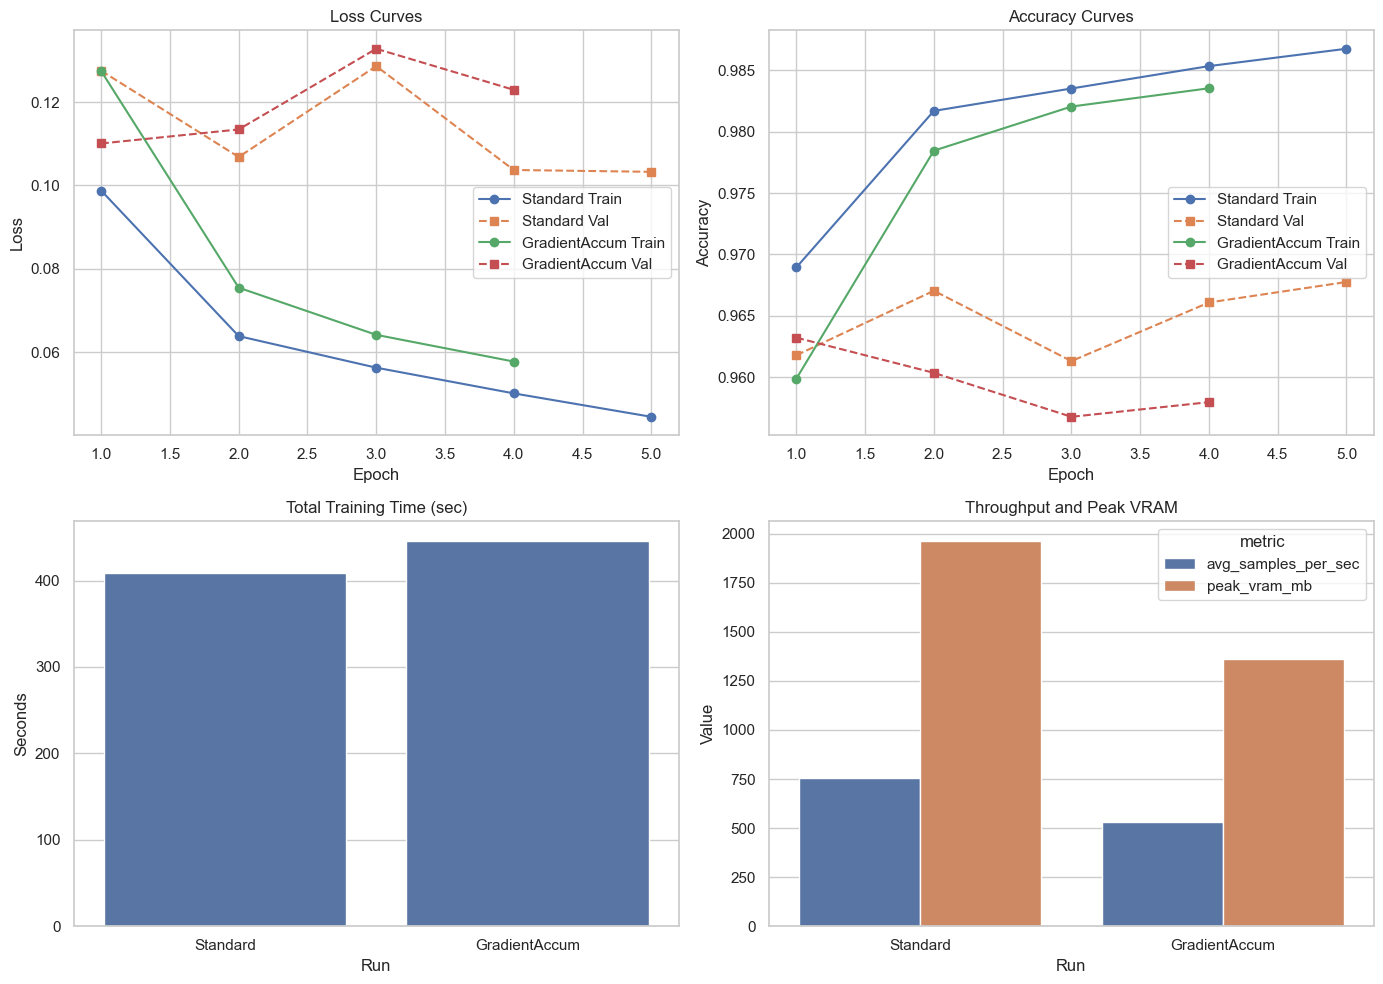

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for label, epoch_df in [('Standard', std_epoch), ('GradientAccum', acc_epoch)]:
    train_df = epoch_df[epoch_df['phase'] == 'train']
    val_df = epoch_df[epoch_df['phase'] == 'val']

    axes[0, 0].plot(train_df['epoch'], train_df['loss'], marker='o', label=f'{label} Train')
    if len(val_df):
        axes[0, 0].plot(val_df['epoch'], val_df['loss'], marker='s', linestyle='--', label=f'{label} Val')

    axes[0, 1].plot(train_df['epoch'], train_df['accuracy'], marker='o', label=f'{label} Train')
    if len(val_df):
        axes[0, 1].plot(val_df['epoch'], val_df['accuracy'], marker='s', linestyle='--', label=f'{label} Val')

axes[0, 0].set_title('Loss Curves')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

sns.barplot(data=comparison_df, x='run', y='total_train_time_sec', ax=axes[1, 0])
axes[1, 0].set_title('Total Training Time (sec)')
axes[1, 0].set_xlabel('Run')
axes[1, 0].set_ylabel('Seconds')

bar_data = comparison_df.melt(
    id_vars=['run'],
    value_vars=['avg_samples_per_sec', 'peak_vram_mb'],
    var_name='metric',
    value_name='value',
)
sns.barplot(data=bar_data, x='run', y='value', hue='metric', ax=axes[1, 1])
axes[1, 1].set_title('Throughput and Peak VRAM')
axes[1, 1].set_xlabel('Run')
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [9]:
hardware_df = comparison_df[[
    'run',
    'peak_vram_mb',
    'max_cpu_percent',
    'max_ram_percent',
    'avg_epoch_time_sec',
    'avg_step_time_sec',
    'avg_samples_per_sec',
    'avg_batches_per_sec',
]]
hardware_df

,run,peak_vram_mb,max_cpu_percent,max_ram_percent,avg_epoch_time_sec,avg_step_time_sec,avg_samples_per_sec,avg_batches_per_sec
0,Standard,1964.549316,58.5,56.2,71.885042,0.037660,757.358551,23.669659
1,GradientAccum,1360.038086,62.6,56.7,101.102121,0.012012,532.877938,66.615945


## Sonuc Notlari

Bu hucrede iki kosunun trade-off analizini kisa maddeler halinde yazin:
- Hangi kosu daha hizli?
- Hangi kosu daha az VRAM kullandi?
- Accuracy/Loss farki anlamli mi?
- Donanim kisitli ortamlarda hangi ayar tercih edilmeli?